num of hvg
使用stripplot绘制CBDir

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/hindbrain.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('Neural stem cells', 'Proliferating VZ progenitors'),
 ('Proliferating VZ progenitors', 'VZ progenitors'),
 ('VZ progenitors', 'Differentiating GABA interneurons'),
 ('VZ progenitors', 'Gliogenic progenitors'),
 ('Differentiating GABA interneurons', 'GABA interneurons')]

In [5]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
data = 'hvg_hindbrain'
save_dir = f'../figures_new/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [6]:
metric_name = 'cbdir'
basis = 'tsne'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results_all = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    results = {}
    for model in models:
        result = {}
        for n_hvg in range(3000, 10000, 1000):
            file_name = f'{metric_name}_{model}_velocity_{basis}' if model in ['latentvelo', 'velovgi'] else f'{metric_name}_{basis}_{model}_velocity' if model != 'scvelo' else f'{metric_name}_{basis}_scvelo_dynamical_velocity'
            metric_file = f'{base_dir}/{data}/{model}/{str(n_hvg)}/{file_name}.pkl'
            with open(metric_file, 'rb') as f:
                metric = pkl.load(f)
            result[n_hvg] = metric[edge]
        if model == 'deepvelo_cui':
            results['deepvelo(cui)'] = result
        else:
            results[model] = result
        if model == 'stt':
            for n_hvg in range(3000, 10000, 1000):
                file_name = f'{metric_name}_{basis}_vj'
                metric_file = f'{base_dir}/{data}/{model}/{str(n_hvg)}/{file_name}.pkl'
                with open(metric_file, 'rb') as f:
                    metric = pkl.load(f)
                result[n_hvg] = metric[edge]
            results['stt(vj)'] = result
        if model == 'latentvelo':
            for n_hvg in range(3000, 10000, 1000):
                file_name = f'{metric_name}_spliced_velocity_{basis}'
                metric_file = f'{base_dir}/{data}/{model}/{str(n_hvg)}/{file_name}.pkl'
                with open(metric_file, 'rb') as f:
                    metric = pkl.load(f)
                result[n_hvg] = metric[edge]
            results['latentvelo(lt)'] = result
    results_all[edge] = results
results_all

{'Neural stem cells -> Proliferating VZ progenitors': {'scvelo': {3000: [0.8743529806243491,
    0.9617155026068112,
    0.9996951272118267,
    -0.26534961284578806,
    -0.235739920847203,
    0.957525341049184,
    0.4755210236120142,
    0.8227035365697654,
    0.9995147161836162,
    0.9046946814099226,
    -0.9509183926974217,
    0.9683868382873181,
    0.4709471863429286,
    0.9344153874278107,
    0.9941008727216946,
    0.963264165211021,
    0.9967472060950926,
    0.4725573973509896,
    0.0928089162803082,
    0.7960764969218136,
    0.7550439559721198,
    0.7627199769940441,
    0.17246325220737135,
    -0.44538967343868496,
    0.16183024294727727,
    0.8977054246650374,
    0.8179816795674804,
    0.6080534394176147,
    0.9058537105226597,
    0.9911525484949067,
    0.8799076368449266,
    0.20038030637720747,
    0.7595844158196656,
    0.1692838578689788,
    0.5429567881810081,
    0.0985816987897441,
    0.6967028949697261,
    -0.022471115529594875,
    -0.676

In [7]:
results_sorted = {}
for edge, results in results_all.items():
    df = pd.DataFrame([(model, n_hvg, value) for model, result in results.items() for n_hvg, values in result.items() for value in values], columns=['model', 'n_hvg', metric_name])
    results_sorted[edge] = df
results_sorted

{'Neural stem cells -> Proliferating VZ progenitors':          model  n_hvg     cbdir
 0       scvelo   3000  0.874353
 1       scvelo   3000  0.961716
 2       scvelo   3000  0.999695
 3       scvelo   3000 -0.265350
 4       scvelo   3000 -0.235740
 ...        ...    ...       ...
 49977  velovgi   9000 -0.296759
 49978  velovgi   9000 -0.975433
 49979  velovgi   9000  0.989886
 49980  velovgi   9000  0.184114
 49981  velovgi   9000  0.131256
 
 [49982 rows x 3 columns],
 'Proliferating VZ progenitors -> VZ progenitors':          model  n_hvg     cbdir
 0       scvelo   3000  0.687003
 1       scvelo   3000 -0.547029
 2       scvelo   3000  0.852779
 3       scvelo   3000  0.773516
 4       scvelo   3000  0.978800
 ...        ...    ...       ...
 38641  velovgi   9000 -0.379628
 38642  velovgi   9000 -0.142376
 38643  velovgi   9000 -0.011169
 38644  velovgi   9000 -0.731632
 38645  velovgi   9000 -0.849391
 
 [38646 rows x 3 columns],
 'VZ progenitors -> Differentiating GABA intern

In [6]:
# color_maps = [plt.cm.YlOrBr, plt.cm.OrRd, plt.cm.RdPu, plt.cm.PuBu, plt.cm.BuGn]

/tmp/ipykernel_3653621/2430355513.py:7: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.5}` instead.

  sns.pointplot(data=df, x=metric_name, y='model', hue='n_hvg', dodge=.8 - .8 / 7, ax=axs[i], capsize=0.02, errwidth=0.5,
/tmp/ipykernel_3653621/2430355513.py:7: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.5}` instead.

  sns.pointplot(data=df, x=metric_name, y='model', hue='n_hvg', dodge=.8 - .8 / 7, ax=axs[i], capsize=0.02, errwidth=0.5,
/tmp/ipykernel_3653621/2430355513.py:7: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.5}` instead.

  sns.pointplot(data=df, x=metric_name, y='model', hue='n_hvg', dodge=.8 - .8 / 7, ax=axs[i], capsize=0.02, errwidth=0.5,
/tmp/ipykernel_3653621/2430355513.py:7: FutureWarning: 

The `errwidth` parameter is deprecated. And will be remove

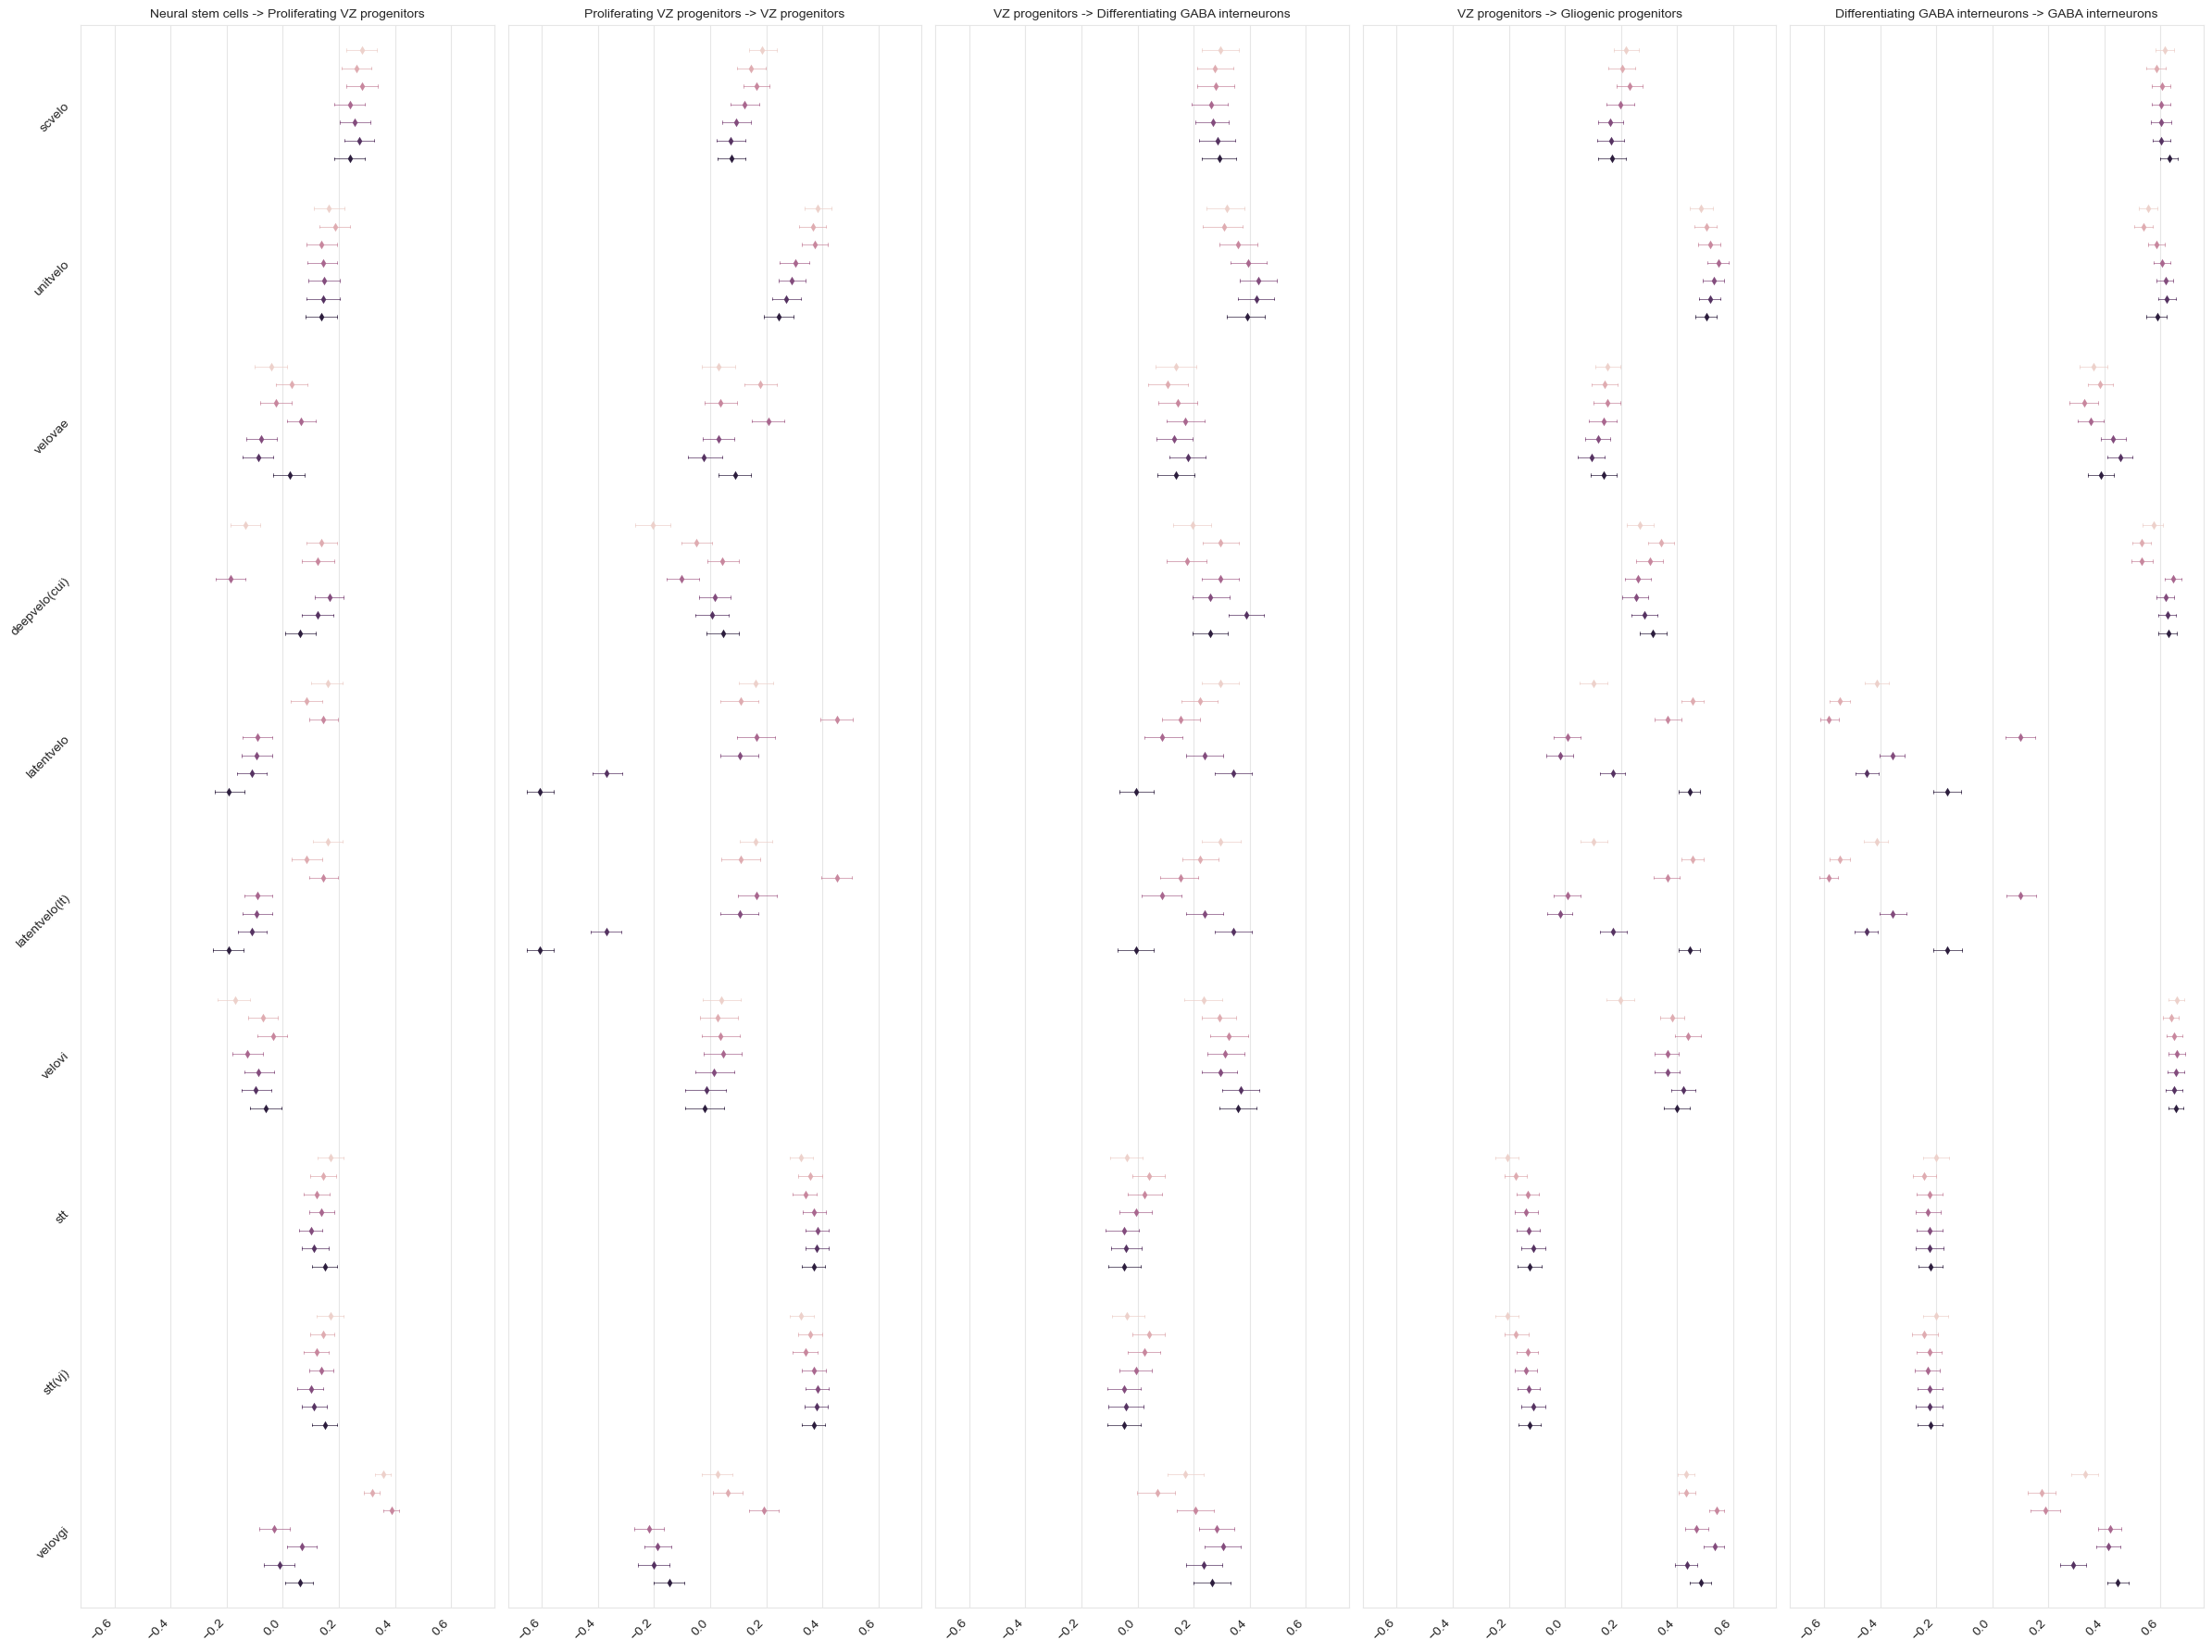

In [15]:
fig, axs = plt.subplots(1, len(results_sorted),sharex=True, sharey=True, figsize=(24, 18))
for i, (edge, df) in enumerate(results_sorted.items()):
    # n_hvg_list = df['n_hvg'].unique()
    # n_hvg_colors = color_maps[i](np.linspace(0.4, 1.0, len(n_hvg_list)))
    # n_hvg_map = dict(zip(n_hvg_list, n_hvg_colors))
    # sns.stripplot(data=df, x=metric_name, y='model', hue='n_hvg', dodge=True, ax=axs[i], alpha=.1, size=1, legend=False)#, palette=n_hvg_map)
    sns.pointplot(data=df, x=metric_name, y='model', hue='n_hvg', dodge=.8 - .8 / 7, ax=axs[i], capsize=0.02, errwidth=0.5,
    markers="d", markersize=2, linestyle="none", legend=False)
    axs[i].set_title(edge, fontsize=10)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.pdf', bbox_inches='tight')
plt.show()